In [ ]:
pip install datasets

# Imports Tools

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torch.utils.data import DataLoader
from datasets import Dataset

# Load Dataset

In [ ]:
data = pd.read_csv("/content/Combined Data.csv")

# Drop Unnamed column
data = data.drop(columns=['Unnamed: 0'])
data.dropna(inplace=True)

data

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
53040,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53041,"selfishness ""I don't feel very good, it's lik...",Anxiety
53042,Is there any way to sleep better? I can't slee...,Anxiety
53043,"Public speaking tips? Hi, all. I have to give ...",Anxiety


In [ ]:
data = data.sample(n=6000,).reset_index(drop=True)
data

,statement,status
0,Hourly employees start arriving at 4am and the...,Stress
1,I have been struggling with depression since m...,Suicidal
2,Morning,Normal
3,Fucking hate you,Anxiety
4,Is anyone else just like full blown depressed ...,Depression
...,...,...
5995,so there is this older women i really like tha...,Depression
5996,I got 5 of 300 welbutrin XL Is it enough I loo...,Suicidal
5997,"I was recently diagnosed with bipolar, is this...",Bipolar
5998,"yes, i did.",Normal


# Data prerpocessing

1 Cleaning

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_statement(statement):
    statement = statement.lower()
    statement = re.sub(r'[^\w\s]', '', statement)
    statement = re.sub(r'\d+', '', statement)
    words = statement.split()
    words = [word for word in words if word not in stop_words]

    # Rejoin words into a cleaned statement
    cleaned_statement = ' '.join(words)

    return cleaned_statement

# Apply the cleaning function to the 'statement' column
data['statement'] = data['statement'].apply(clean_statement)

data

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,statement,status
0,hourly employees start arriving managers deleg...,Stress
1,struggling depression since midlate teens coll...,Suicidal
2,morning,Normal
3,fucking hate,Anxiety
4,anyone else like full blown depressed ready di...,Depression
...,...,...
5995,older women really like work liked awhile peop...,Depression
5996,got welbutrin xl enough looked google understa...,Suicidal
5997,recently diagnosed bipolar symptom experience ...,Bipolar
5998,yes,Normal


2 balance dataset

In [ ]:
data['status'].value_counts()

,count
status,
Normal,1826
Depression,1790
Suicidal,1209
Anxiety,440
Stress,300
Bipolar,296
Personality disorder,139


In [ ]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# Create an instance of RandomOverSampler
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)

# Define features (X) and target (y)
X = data.drop(columns=['status'])
y = data['status']

# Perform oversampling
X_resampled, y_resampled = ros.fit_resample(X, y)

# Combine the oversampled features and target back into a DataFrame
data = pd.concat([X_resampled, y_resampled], axis=1)

# Check the new class distribution
print(data['status'].value_counts())


status
Stress                  1826
Suicidal                1826
Normal                  1826
Anxiety                 1826
Depression              1826
Bipolar                 1826
Personality disorder    1826
Name: count, dtype: int64


 3 Encoding *Status*

In [ ]:
# Label encoding for 'status' column
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['status'])

# Train Test Split

In [ ]:
# Split data into train and test
train_texts, test_texts, train_labels, test_labels = train_test_split(data['statement'], data['label'], test_size=0.2)

In [ ]:
max([len(text) for text in data['statement']])

7176

# Tokenization

In [ ]:
# Tokenization using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


train_encodings = tokenizer(list(train_texts), padding=True, truncation=True, max_length=200)
test_encodings = tokenizer(list(test_texts), padding=True, truncation=True, max_length=200)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Convert to Dataset format
train_dataset = Dataset.from_dict({'input_ids': train_encodings['input_ids'], 'attention_mask': train_encodings['attention_mask'], 'labels': train_labels.tolist()})
test_dataset = Dataset.from_dict({'input_ids': test_encodings['input_ids'], 'attention_mask': test_encodings['attention_mask'], 'labels': test_labels.tolist()})



# Fine Tuning Bert

In [ ]:

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(label_encoder.classes_))

training_args = TrainingArguments(
    output_dir="./results",          # Output directory for results
    eval_strategy="epoch",     # Evaluate once per epoch
    save_strategy="epoch",          # Save model at the end of each epoch to match evaluation strategy
    learning_rate=2e-5,              # Learning rate
    per_device_train_batch_size=16,  # Batch size for training
    per_device_eval_batch_size=16,   # Batch size for evaluation
    num_train_epochs=5,              # Increase number of epochs
    weight_decay=0.01,               # Strength of weight decay
    logging_dir="./logs",            # Directory for logging
    logging_steps=10,                # Log every 10 steps
    lr_scheduler_type="linear",      # Use linear learning rate scheduler with warmup
    warmup_steps=500,                # Number of warmup steps for learning rate scheduler
    load_best_model_at_end=True,     # Load the best model at the end of training
    metric_for_best_model="eval_loss", # Monitor eval loss to determine the best model
    save_total_limit=3,              # Limit the number of checkpoints to save
    gradient_accumulation_steps=2    # Simulate larger batch size if GPU memory is limited
)
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

In [ ]:

# Fine-tuning the model
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time
1,1.009600,0.997551,0.002900


KeyboardInterrupt: 

#  Model Evaluation


wandb: Currently logged in as: scorer8756 (scorer8756-student) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                      precision    recall  f1-score   support

             Anxiety       0.00      0.00      0.00       348
             Bipolar       0.00      0.00      0.00       367
          Depression       0.00      0.00      0.00       400
              Normal       0.22      0.86      0.35       361
Personality disorder       0.00      0.00      0.00       388
              Stress       0.13      0.37      0.19       406
            Suicidal       0.00      0.00      0.00       334

            accuracy                           0.18      2604
           macro avg       0.05      0.18      0.08      2604
        weighted avg       0.05      0.18      0.08      2604



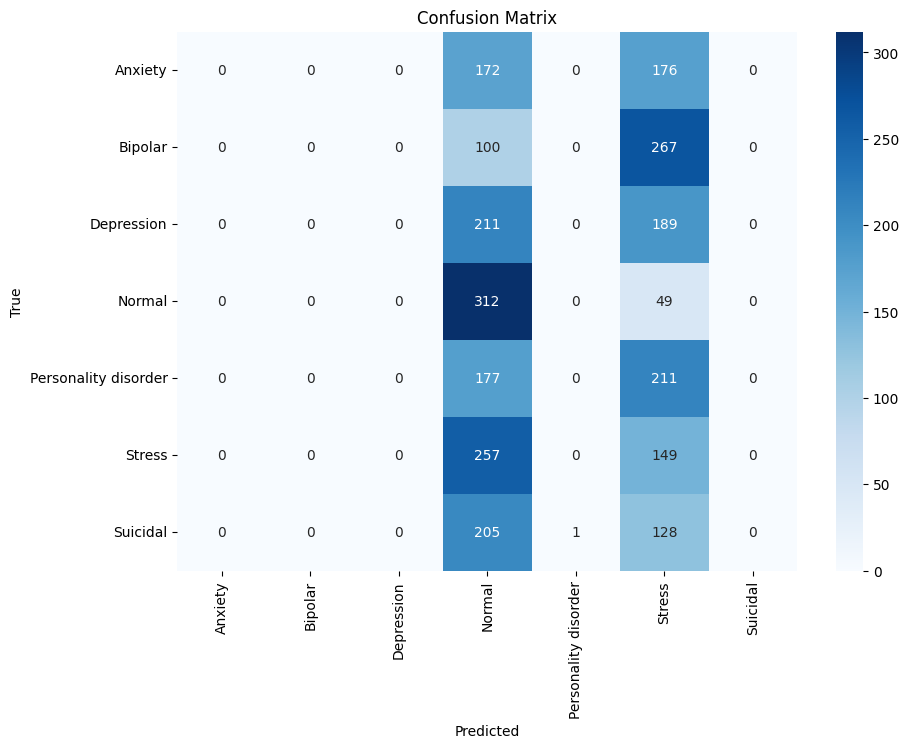

In [ ]:
# Predictions
predictions, labels, _ = trainer.predict(test_dataset)

# Convert predictions to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Classification Report
print(classification_report(test_labels, predicted_labels, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
metrics_df["Support"].plot(kind="bar", color="lightblue")
plt.title("Number of Samples per Class (Support)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

NameError: name 'metrics_df' is not defined

<Figure size 800x400 with 0 Axes>

# Save and Load Model and Tokenizer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Save the trained model and tokenizer
#trainer.save_model("/content/drive/MyDrive/saved_mental_status_bert")  # Save the model to the specified directory
#tokenizer.save_pretrained("/content/drive/MyDrive/saved_mental_status_bert")  # Save the tokenizer


#import pickle

#pickle.dump(label_encoder, open('/content/drive/MyDrive/label_encoder.pkl', 'wb'))

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

import pickle
# Load the model and tokenizer from the saved paths
model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/saved_mental_status_bert")
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/saved_mental_status_bert")

label_encoder = pickle.load(open('/content/drive/MyDrive/label_encoder.pkl', 'rb'))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from huggingface_hub import notebook_login
notebook_login()  # get token from huggingface.co/settings/tokens

In [ ]:
import pickle
from huggingface_hub import HfApi

# Push model and tokenizer
model.push_to_hub("tyagi-ashu/mental-health-classifier")
tokenizer.push_to_hub("tyagi-ashu/mental-health-classifier")

# Push label encoder separately
api = HfApi()
api.upload_file(
    path_or_fileobj="/content/drive/MyDrive/label_encoder.pkl",
    path_in_repo="label_encoder.pkl",
    repo_id="tyagi-ashu/mental-health-classifier"
)

print("Done!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...fugd3m7/model.safetensors:   0%|          | 14.2kB /  438MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...MyDrive/label_encoder.pkl: 100%|##########|   328B /   328B            

Done!


In [ ]:
# Fix label mappings
id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}

print("id2label:", id2label)
# Should show: {0: 'Anxiety', 1: 'Bipolar', 2: 'Depression', 3: 'Normal', 4: 'Personality disorder', 5: 'Stress', 6: 'Suicidal'}

model.config.id2label = id2label
model.config.label2id = label2id

# Re-push
model.push_to_hub("tyagi-ashu/mental-health-classifier")
tokenizer.push_to_hub("tyagi-ashu/mental-health-classifier")
print("Done!")

id2label: {0: 'Anxiety', 1: 'Bipolar', 2: 'Depression', 3: 'Normal', 4: 'Personality disorder', 5: 'Stress', 6: 'Suicidal'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._4_nup_/model.safetensors:  16%|#6        | 72.0MB /  438MB            

Done!


In [ ]:
# Verify fix worked
print("id2label:", model.config.id2label)

text = "I am suicidal and want to end my life"
cleaned = clean_statement(text)
inputs = tokenizer(cleaned, return_tensors="pt", padding=True, truncation=True, max_length=512)
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predicted_idx = torch.argmax(logits, dim=1).item()
print("Logits:", logits)
print("Predicted index:", predicted_idx)
print("Predicted label:", model.config.id2label[predicted_idx])

id2label: {0: 'Anxiety', 1: 'Bipolar', 2: 'Depression', 3: 'Normal', 4: 'Personality disorder', 5: 'Stress', 6: 'Suicidal'}
Logits: tensor([[-1.2723, -1.4348,  2.5751, -1.3394, -2.1912, -1.0746,  4.9383]])
Predicted index: 6
Predicted label: Suicidal


# Detection System

In [ ]:
# Detection System
device = torch.device("cpu")
model.to(device)
def detect_anxiety(text):
    cleaned_text = clean_statement(text)
    inputs = tokenizer(cleaned_text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()
    return predicted_class

# Test detection system with a mixture of normal, anxiety, bipolar, depression, suicide, etc.
sample_texts = [
    "I feel perfectly fine today, nothing to worry about.",
    "I can't stop thinking about what will happen if things go wrong.",
    "Lately, I've been on a high, feeling like I can do anything!",
    "I'm so sad, I just can't seem to get out of bed anymore.",
    "I'm constantly thinking about how much better everyone else is doing than me.",
    "I don't think I can keep going, everything feels so hopeless.",
    "I had a really good day, spent some time with my friends.",
    "I'm overwhelmed by the idea that I might lose everything.",
    "I feel like nothing matters anymore, I just want to give up.",
    "I'm okay today, but sometimes I get really anxious for no reason."
]

# detect_anxiety function takes a sentence as input
for text in sample_texts:
    predicted_class = label_encoder.inverse_transform([detect_anxiety(text)])[0]
    print(f"Sentence: {text}\nPredicted class: {predicted_class}\n")


Sentence: I feel perfectly fine today, nothing to worry about.
Predicted class: Anxiety

Sentence: I can't stop thinking about what will happen if things go wrong.
Predicted class: Normal

Sentence: Lately, I've been on a high, feeling like I can do anything!
Predicted class: Anxiety

Sentence: I'm so sad, I just can't seem to get out of bed anymore.
Predicted class: Normal

Sentence: I'm constantly thinking about how much better everyone else is doing than me.
Predicted class: Normal

Sentence: I don't think I can keep going, everything feels so hopeless.
Predicted class: Suicidal

Sentence: I had a really good day, spent some time with my friends.
Predicted class: Normal

Sentence: I'm overwhelmed by the idea that I might lose everything.
Predicted class: Normal

Sentence: I feel like nothing matters anymore, I just want to give up.
Predicted class: Suicidal

Sentence: I'm okay today, but sometimes I get really anxious for no reason.
Predicted class: Anxiety



SHAP

In [ ]:
import shap


In [ ]:
model.eval()
# Move model to GPU if available
device = torch.device("cpu")    # cuda or cpu
model.to(device)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
#data
background_texts = (
    data.groupby('label')
      .apply(lambda x: x.sample(min(10, len(x)), random_state=42))
      ['statement']
      .tolist()
)

background_texts

/tmp/ipykernel_564/2888254767.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(10, len(x)), random_state=42))


['im terrified college future im senior high school year flown fast ive dreading graduation since junior year realized coming quicker thought cant even decide college pickbetween ive always indecisive im afraid might hate either way also social anxiety im scared ill end alone dont wanna avoid college dont want let anxiety win also dont know dont go college feel like high school life bleak family little money inflation skyrocketing im afraid poor whole life depression low self esteem felt hopeless im also scared lose friends go college im sure lot panic attacks leading im scared',
 'ive missed weeks class im embarrassed go backwhat hi ive recently started medication help manage anxiety adjusting medication noticed helped society anxiety lot stopped caring however downside started become apathetic everything lost lot motivation even get bedgo class ive recently started new medication far feelings apathylack productivity improved finish tasks still perfect feel like low starting dose feel

In [ ]:
type(background_texts)

list

In [ ]:
clf = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,    #0 for gpu -1 for cpu
    top_k=None
)
clf(["I feel hopeless", "I'm doing fine"])


[[{'label': 'Normal', 'score': 0.9262609481811523},
  {'label': 'Depression', 'score': 0.029775163158774376},
  {'label': 'Suicidal', 'score': 0.027052253484725952},
  {'label': 'Anxiety', 'score': 0.008973776362836361},
  {'label': 'Stress', 'score': 0.003583767218515277},
  {'label': 'Personality disorder', 'score': 0.0028887588996440172},
  {'label': 'Bipolar', 'score': 0.001465321402065456}],
 [{'label': 'Normal', 'score': 0.9708280563354492},
  {'label': 'Suicidal', 'score': 0.011066155508160591},
  {'label': 'Depression', 'score': 0.00678466958925128},
  {'label': 'Anxiety', 'score': 0.0050953952595591545},
  {'label': 'Stress', 'score': 0.003939254675060511},
  {'label': 'Bipolar', 'score': 0.0012480404693633318},
  {'label': 'Personality disorder', 'score': 0.0010383835760876536}]]

In [ ]:
def predict_proba(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    clean_texts = [
        " ".join(t) if isinstance(t, (list, tuple)) else str(t)
        for t in texts
    ]
    outputs = clf(clean_texts)

    # When SHAP probes a single text internally, pipeline returns a flat
    # list of dicts instead of a list-of-lists — normalize it
    if outputs and isinstance(outputs[0], dict):
        outputs = [outputs]

    return np.array([
        [d['score'] for d in sorted(o, key=lambda x: x['label'])]
        for o in outputs
    ])

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker, algorithm="partition")


In [ ]:
test_text = ["I don't see the point of living anymore.","I feel great today, everything is wonderful.","I feel great today, everything is wonderful. I don't see the point of living anymore. I'm completely hopeless."]

shap_values = explainer(test_text)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
PartitionExplainer explainer: 4it [00:13, 13.78s/it]               


In [ ]:
#shap.plots.text(shap_values[0])   #seeing all
for i in range(len(test_text)):
  label_index=detect_anxiety(test_text[i])
  label_name=label_encoder.inverse_transform([label_index])[0]
  print(f"Prediction: {label_name}")
  shap.plots.text(shap_values[i, :, label_index])



Prediction: Suicidal


Prediction: Normal


Prediction: Depression


In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.1 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import pickle
import re
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords (only needed once)
nltk.download('stopwords')

# load save model
#model = AutoModelForSequenceClassification.from_pretrained('saved_mental_status_bert')
#tokenizer = AutoTokenizer.from_pretrained('saved_mental_status_bert')
#label_encoder = pickle.load(open('label_encoder.pkl','rb'))


# custom function
# Get English stopwords from NLTK
stop_words = set(stopwords.words('english'))
def clean_statement(statement):
    # Convert to lowercase
    statement = statement.lower()

    # Remove special characters (punctuation, non-alphabetic characters)
    statement = re.sub(r'[^\w\s]', '', statement)

    # Remove numbers (optional, depending on your use case)
    statement = re.sub(r'\d+', '', statement)

    # Tokenize the statement (split into words)
    words = statement.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Rejoin words into a cleaned statement
    cleaned_statement = ' '.join(words)

    return cleaned_statement
# Detection System (Example)
def detect_anxiety(text):
    cleaned_text = clean_statement(text)
    inputs = tokenizer(cleaned_text, return_tensors="pt", padding=True, truncation=True, max_length=200)
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()
    return label_encoder.inverse_transform([predicted_class])[0]
# UI app
st.title("Mental Health Status Detection Bert")

input_text = st.text_input("Enter Your mental state here....")

if st.button("detect"):
    predicted_class = detect_anxiety(input_text)
    st.write("Predicted Status :", predicted_class)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2026-03-19 06:54:04.105 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 06:54:04.430 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-19 06:54:04.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 06:54:04.443 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 06:54:04.450 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 06:54:04.452 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 06:54:04.457 Thread 'MainThread': missing S

In [ ]:
!pip install pyngrok


In [ ]:
!curl ipv4.icanhazip.com

8.228.4.58


In [ ]:
from pyngrok import ngrok
!ngrok config add-authtoken 3B9aeR4Kk4PDFBh2SXJjXzMfOKy_7mZsJRPvegmdSn1N2sHq6
!npm install -g localtunnel
!npx localtunnel --port 8501

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 995ms
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://short-crews-warn.loca.lt
^C


In [ ]:
!streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py &>/content/logs.txt &